In [1]:
import numpy as np
from collections import OrderedDict
import math
import numpy as np
import pandas as pd
import pymeasure
from time import sleep, time
from matplotlib import pyplot as plt
from matplotlib import style
from datetime import datetime
from pymeasure.instruments.keithley import Keithley2400
from pymeasure.instruments.keithley import Keithley2000
import matplotlib.cm as cm
from glob import glob
import os
import sys

In [2]:
myKeithley = Keithley2400(4)

In [3]:
myKeithley.source_voltage

-80.0

In [6]:
myKeithley.current

-1.041244e-11

In [4]:
myKeithley.adapter.connection.timeout

3000

In [3]:
def ramp_to_voltage_and_confirm(desiredvoltage,steps = 60,pause=0.2):
    print(f"setting voltage to {desiredvoltage}")
    myKeithley.ramp_to_voltage(desiredvoltage, steps=steps, pause=pause)

    nowishVoltage = np.nan

    while nowishVoltage != desiredvoltage:
        try:
            nowishVoltage = myKeithley.source_voltage
        except:
            print("it didn't like it")

        print(f"voltage at {nowishVoltage}")
        sleep(2)
    
    print(f"Finalized voltage at {myKeithley.source_voltage}")

In [4]:
ramp_to_voltage_and_confirm(0, steps = 200)

setting voltage to 0
voltage at 0.0
Finalized voltage at 0.0


In [21]:
pwrOf2 = -35;
# (pwrOf2 < -20)
(pwrOf2 > -40)
# ~((pwrOf2 < -20) & (pwrOf2 > -40))

True

In [26]:
not(False)

True

In [4]:
def get_current_and_confirm():
    questionable = myKeithley.current
    pwrOf2 = math.frexp(questionable)[1]
    while not((pwrOf2 < -20) & (pwrOf2 > -40)):
        questionable = myKeithley.current
        pwrOf2 = math.frexp(questionable)[1]
        sleep(0.5)
    return questionable

print(get_current_and_confirm())

-1.159768e-11


In [31]:
myKeithley.source_voltage

2.0

In [136]:
myKeithley.voltage

7.509982e-12

In [139]:
myKeithley.source_voltage

2.0

In [5]:
def gating_rxx(Vmin, Vmax, Vstep,delay, average,file_path,sample_name,stepsperramp):
    VdataPoints= int(np.absolute(Vmax-Vmin)/Vstep)+1
    voltages = np.linspace(Vmin,Vmax,num=VdataPoints)
    data = OrderedDict()
    data['Voltage'], data['leakage'] = [], []
    filename = file_path+'gating2point'+sample_name+'.csv'
    
    # if np.absolute(Vmin/VdataPoints) > 0.1:
    #     myKeithley.ramp_to_voltage(Vmin, steps = int(np.absolute(Vmin/0.25)), pause=0.3)    
    # # Set the ramp rate to Vmin
    # print ('waiting for initial voltage')
    # while abs(myKeithley.source_voltage - Vmin)>0.5:
    #     sleep(3)
    # print ('Intial voltage set at : ' + str(Vmin))
    # sleep(delay)


    for v in voltages:
        ramp_to_voltage_and_confirm(v,stepsperramp)
        # while abs(myKeithley.source_voltage - i)>0.5:
        #     sleep(1)
        # sleep(delay)
        # print ('Voltage : ' + str(i) + ' checked and stabilized')
        
        data['Voltage'].append(v)
        current = get_current_and_confirm()
        print('Current : ' + str(current) + 'A')
        data['leakage'].append(current)
        
        plt.plot(data['Voltage'], data['leakage'])
        plt.xlabel('Gate Voltage',fontsize=18)
        plt.ylabel('Leakage',fontsize=18)
        
        print(f'Measurement done for voltage : {v} ')
        datafram = pd.DataFrame({ 'Voltage': np.transpose(data['Voltage']), 'leakage':np.transpose(data['leakage'])})
        #save dataframe to csv file in the same path and file name
        datafram.to_csv(filename,index=False)

    #reset voltage after experiment
    myKeithley.ramp_to_voltage(0, steps = int(VdataPoints), pause=0.2)


setting voltage to 80.0
voltage at 75.0
voltage at 80.0
Finalized voltage at 80.0
Current : 3.468669e-11A
Measurement done for voltage : 80.0 
setting voltage to 75.0
voltage at 80.0
voltage at 75.0
Finalized voltage at 75.0
Current : 3.354168e-11A
Measurement done for voltage : 75.0 
setting voltage to 70.0
voltage at 75.0
voltage at 70.0
Finalized voltage at 70.0
Current : 3.143253e-11A
Measurement done for voltage : 70.0 
setting voltage to 65.0
voltage at 70.0
voltage at 65.0
Finalized voltage at 65.0
Current : 2.956969e-11A
Measurement done for voltage : 65.0 
setting voltage to 60.0
voltage at 65.0
voltage at 60.0
Finalized voltage at 60.0
Current : 2.782648e-11A
Measurement done for voltage : 60.0 
setting voltage to 55.0
voltage at 60.0
voltage at 55.0
Finalized voltage at 55.0
Current : 2.61452e-11A
Measurement done for voltage : 55.0 
setting voltage to 50.0
voltage at 55.0
voltage at 50.0
Finalized voltage at 50.0
Current : 2.430347e-11A
Measurement done for voltage : 50.0 


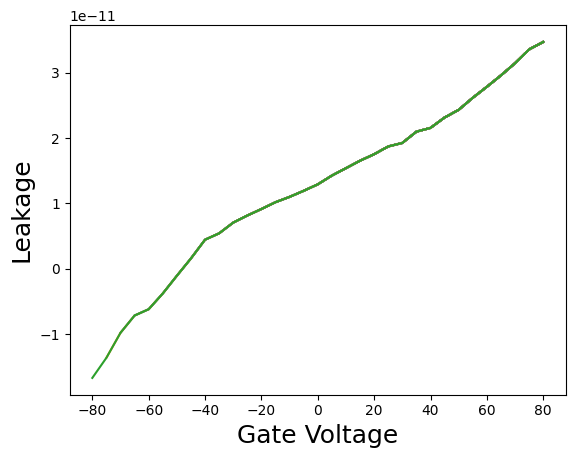

In [8]:
file_path='C:/Users/Ralph Group/Documents/Data/TiffanyFilms/NiFerritePostPaterning/IV/'
sample_name='2450_80V_run9'
average = 1
gating_rxx(80, -80, 5, 1, average,file_path,sample_name,stepsperramp = 20)

In [ ]:
# myKeithley.current

In [ ]:
# df = pd.read_csv('C:/Users/Ralph Group/Documents/Data/TiffanyFilms/NiFerritePostPaterning/IV/gating2pointVoltageVSCurrent.csv')
# plt.plot(df['Voltage'], df['leakage'])